## Problema

Objetivo: detectar transações fraudulentas.

Tipos de erro:
- False Negative → fraude passa (alto custo 💸)
- False Positive → bloqueio indevido (impacto cliente)

Métrica ideal: Recall ou ROC-AUC

In [4]:
import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Carregamento dos dados

In [5]:
df = pd.read_csv('../data/raw/fraud_dataset_20260421_232806.csv')

# Analise inicial do dataframe

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 6 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   valor             200000 non-null  float64
 1   hora              200000 non-null  int64  
 2   dispositivo_novo  200000 non-null  bool   
 3   tentativas_24h    200000 non-null  int64  
 4   distancia_km      200000 non-null  float64
 5   fraude            200000 non-null  int64  
dtypes: bool(1), float64(2), int64(3)
memory usage: 7.8 MB


In [4]:
df.describe()

,valor,hora,tentativas_24h,distancia_km,fraude
count,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000
mean,2507.824323,11.479945,2.494640,996.784190,0.187590
std,1440.187933,6.919832,1.705452,578.038618,0.390385
min,10.030000,0.000000,0.000000,0.010000,0.000000
25%,1262.260000,5.000000,1.000000,497.897500,0.000000
50%,2512.195000,11.000000,2.000000,994.575000,0.000000
75%,3757.280000,17.000000,4.000000,1497.070000,0.000000
max,4999.980000,23.000000,5.000000,2000.000000,1.000000


# Distribuição da variável alvo 

Text(0.5, 1.0, 'Distribuição das Classes (162482: Legitima, 37518: Fraude)')

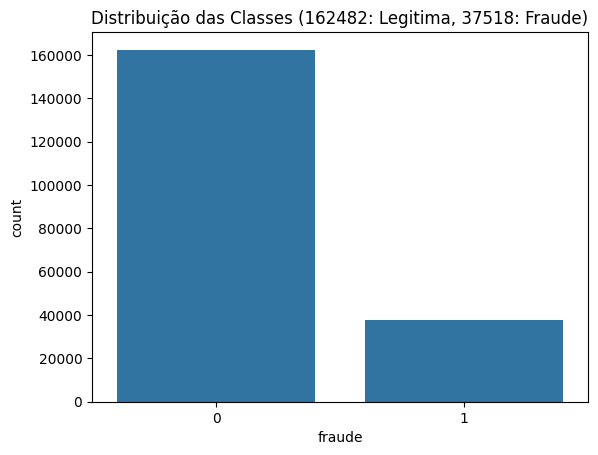

In [5]:
df['fraude'].value_counts()
df_2 = df['fraude'].value_counts()
sns.countplot(x='fraude', data=df)
plt.title(f'Distribuição das Classes ({df_2[0]}: Legitima, {df_2[1]}: Fraude)')

Nota: Dataset muito desbalanceado:

# Correlação entre as variaveis 

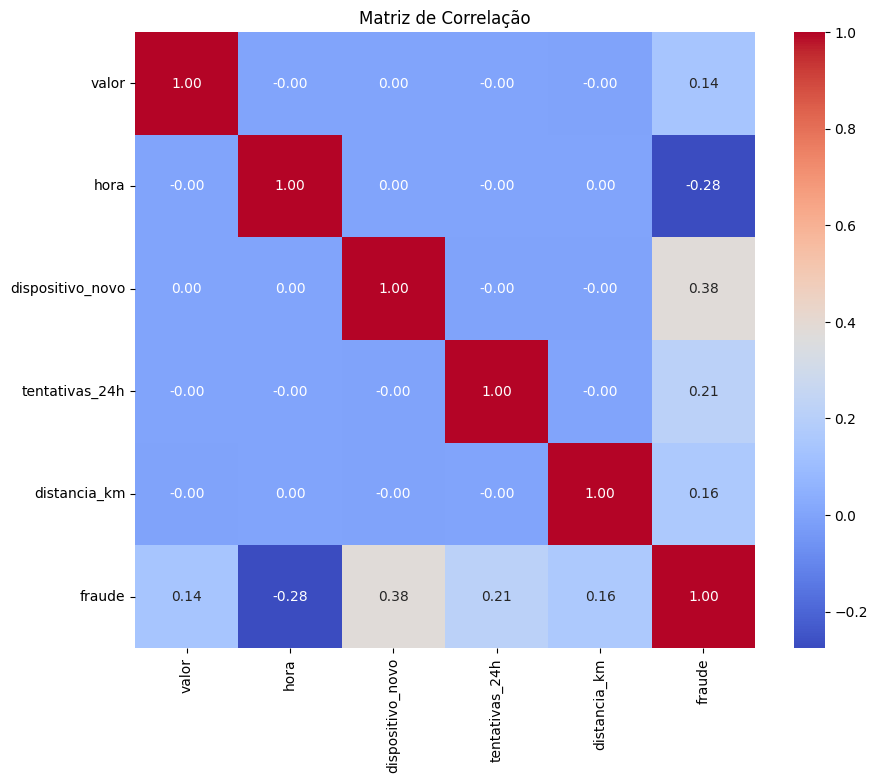

In [6]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de Correlação")
plt.show()

In [7]:
df.corr(numeric_only=True)["fraude"].sort_values(ascending=False)

fraude              1.000000
dispositivo_novo    0.379410
tentativas_24h      0.214013
distancia_km        0.158454
valor               0.141411
hora               -0.275297
Name: fraude, dtype: float64

# Distribuição de Fraude por Hora do Dia

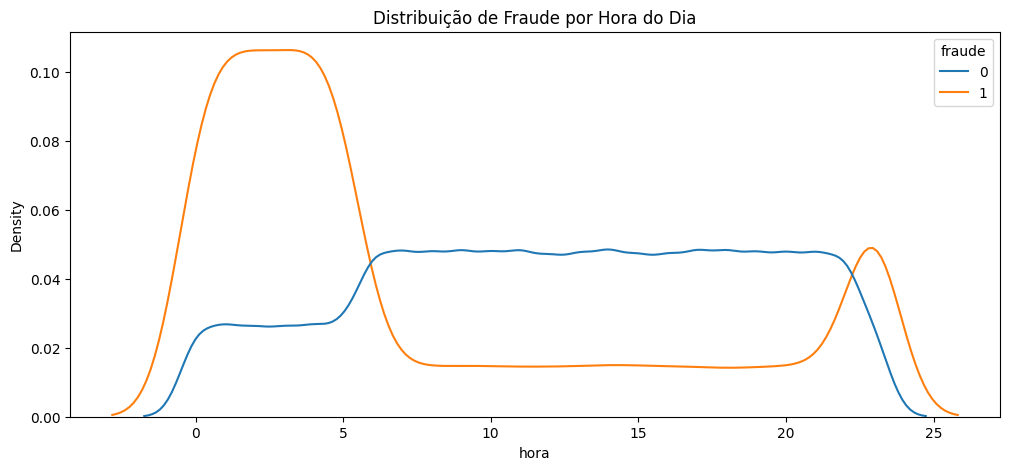

In [8]:
plt.figure(figsize=(12, 5))
sns.kdeplot(data=df, x='hora', hue='fraude', common_norm=False)
plt.title("Distribuição de Fraude por Hora do Dia")
plt.show()

# Distribuição de Valor por Status de Fraude

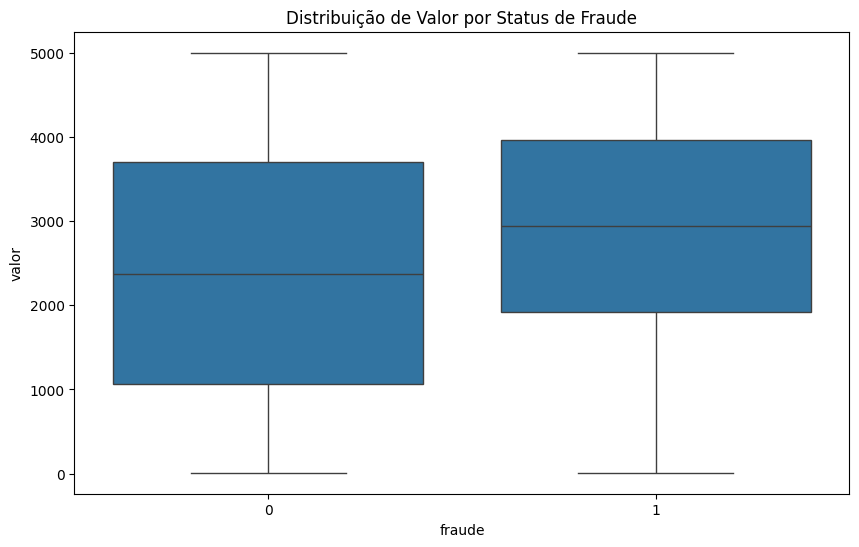

In [9]:
# Comparando Valor e Fraude com Boxplot para ver Outliers
plt.figure(figsize=(10, 6))
sns.boxplot(x='fraude', y='valor', data=df)
plt.title('Distribuição de Valor por Status de Fraude')
plt.show()

<Axes: xlabel='fraude', ylabel='valor'>

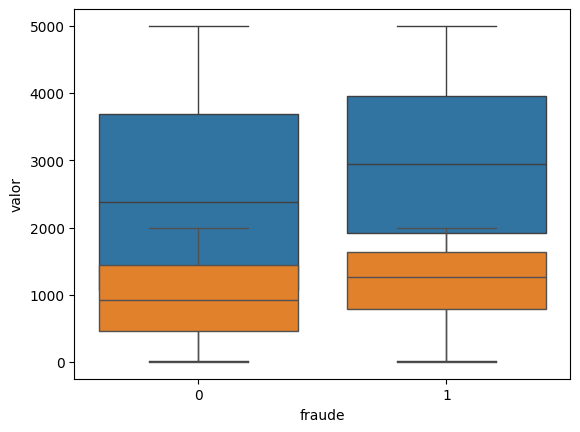

In [10]:
sns.boxplot(x='fraude', y='valor', data=df)
sns.boxplot(x='fraude', y='distancia_km', data=df)

<Axes: xlabel='hora', ylabel='Count'>

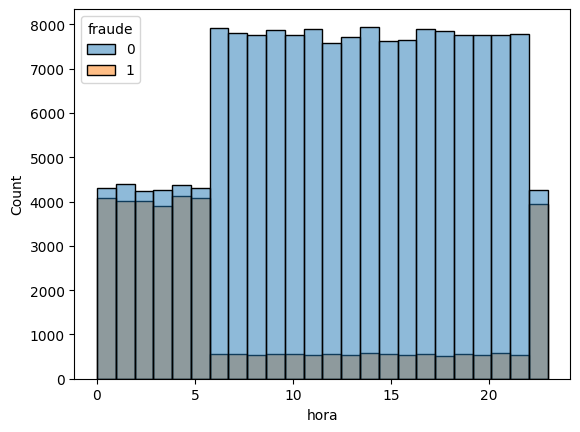

In [11]:
sns.histplot(data=df, x='hora', hue='fraude', bins=24)

# Taxa de fraude por dispositivos

In [12]:
pd.crosstab(df['dispositivo_novo'], df['fraude'], normalize='index')

fraude,0,1
dispositivo_novo,,
False,0.960616,0.039384
True,0.664385,0.335615


# Media de valores por classe

In [13]:
df.groupby("fraude")["valor"].mean()

fraude
0    2409.961104
1    2931.647863
Name: valor, dtype: float64

# Tentativas

<Axes: xlabel='fraude', ylabel='tentativas_24h'>

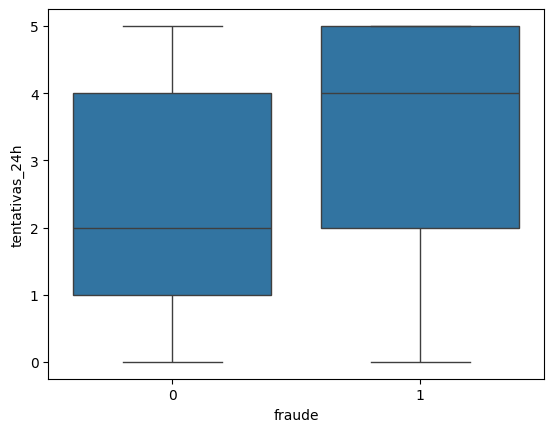

In [14]:
sns.boxplot(x='fraude', y='tentativas_24h', data=df)

# Feature Engineering

Remoção de Viés: tentativas_24h
A coluna tentativas_24h foi removida para garantir a integridade do modelo:

A variável apresentava uma importância desproporcional (dominando o modelo), indicando que continha informação "do futuro" ou retroalimentada pelo sistema após a transação ser suspeita.

Generalização: Sem esse "atalho", o modelo é forçado a aprender padrões comportamentais reais (valor, hora, distância)

Fim do Overfitting: A remoção elimina o score irreal de 1.0, resultando em um modelo que reflete a performance real em produção.

In [15]:
df = df.drop(columns=['tentativas_24h'])

In [16]:
# Transformação Cíclica da Hora (Seno e Cosseno)
df['hora_sin'] = np.sin(2 * np.pi * df['hora'] / 24)
df['hora_cos'] = np.cos(2 * np.pi * df['hora'] / 24)

# Transformação Logarítmica (Suaviza valores altos de Valor e Distância)
df['valor_log'] = np.log1p(df['valor'])
df['distancia_log'] = np.log1p(df['distancia_km'])

# Converte Booleano para 0 e 1
df['dispositivo_novo'] = df['dispositivo_novo'].astype(int)

In [17]:
df = df.drop(columns=['valor', 'distancia_km', 'hora'])

In [18]:
df.head()

,dispositivo_novo,fraude,hora_sin,hora_cos,valor_log,distancia_log
0,1,0,-0.500000,8.660254e-01,7.994588,7.234394
1,0,0,0.965926,-2.588190e-01,7.794687,7.055416
2,0,0,0.965926,-2.588190e-01,6.635330,6.117194
3,1,1,-1.000000,-1.836970e-16,7.669178,7.423551
4,0,0,1.000000,6.123234e-17,5.412315,7.333689


Hipóteses:
- transações noturnas → maior risco
- distância alta + muitas tentativas → comportamento suspeito

# BASELINE MODEL

# 1. Separação correta dos dados

In [19]:

X = df.drop(columns=['fraude'])
y = df['fraude']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# 2. Pipeline Inicial

In [20]:
# 1. Definindo o Pipeline da Regressão Logística
pipeline_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(class_weight='balanced', random_state=42)) 
])

# 2. Definindo o Pipeline da Random Forest
pipeline_rf = Pipeline([
    ('model', RandomForestClassifier(
        max_depth=5, 
        n_estimators=100, 
        random_state=42,
        class_weight='balanced' 
    ))
])

# 3. Treinar baseline

In [21]:
# Treinando e iniciando o tracking no MLflow
with mlflow.start_run(run_name="Logistica_Baseline"):
    pipeline_lr.fit(X_train, y_train)
    # Corrigido: usando 'name' e opcionalmente 'skops'
    mlflow.sklearn.log_model(pipeline_lr, name="model_lr") 
    mlflow.log_params(pipeline_lr.named_steps['model'].get_params())

with mlflow.start_run(run_name="RF_Baseline"):
    pipeline_rf.fit(X_train, y_train)
    # Corrigido: usando 'name'
    mlflow.sklearn.log_model(pipeline_rf, name="model_rf")
    mlflow.log_params(pipeline_rf.named_steps['model'].get_params())

2026/04/22 21:39:27 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/22 21:39:43 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


# 4. Métricas

In [22]:


def avaliar_modelo(nome, pipeline, X_test, y_test, run_name):
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    
    # Cálculos das métricas
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    f1 = f1_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)

    # Logar métricas no MLflow
    with mlflow.start_run(run_name=run_name, nested=True):
        mlflow.log_metrics({
            "accuracy": acc, 
            "auc_roc": auc, 
            "f1_score": f1,
            "precision": precision,
            "recall": recall
        })

    print(f"--- Relatório: {nome} ---")
    print(f"Acurácia:  {acc:.4f}")
    print(f"AUC-ROC:   {auc:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print("\nMatriz de Confusão:")
    print(confusion_matrix(y_test, y_pred))
    print("\nRelatório de Classificação:")
    print(classification_report(y_test, y_pred))
    print("-" * 30 + "\n")

# Uso:
avaliar_modelo("Logística", pipeline_lr, X_test, y_test, "Logistica_Baseline")
avaliar_modelo("Random Forest", pipeline_rf, X_test, y_test, "RF_Baseline")

--- Relatório: Logística ---
Acurácia:  0.8224
AUC-ROC:   0.9202
F1-Score:  0.6307
Precision: 0.5171
Recall:    0.8082

Matriz de Confusão:
[[26831  5665]
 [ 1439  6065]]

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.95      0.83      0.88     32496
           1       0.52      0.81      0.63      7504

    accuracy                           0.82     40000
   macro avg       0.73      0.82      0.76     40000
weighted avg       0.87      0.82      0.84     40000

------------------------------

--- Relatório: Random Forest ---
Acurácia:  0.8594
AUC-ROC:   0.9673
F1-Score:  0.7272
Precision: 0.5716
Recall:    0.9991

Matriz de Confusão:
[[26878  5618]
 [    7  7497]]

Relatório de Classificação:
              precision    recall  f1-score   support

           0       1.00      0.83      0.91     32496
           1       0.57      1.00      0.73      7504

    accuracy                           0.86     40000
   macro avg       

# 5. Feature importance

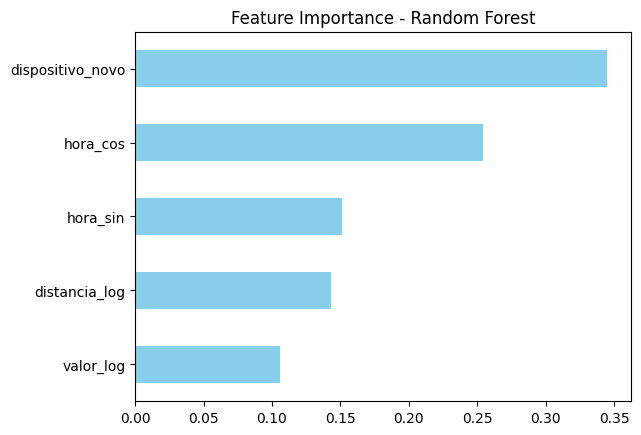

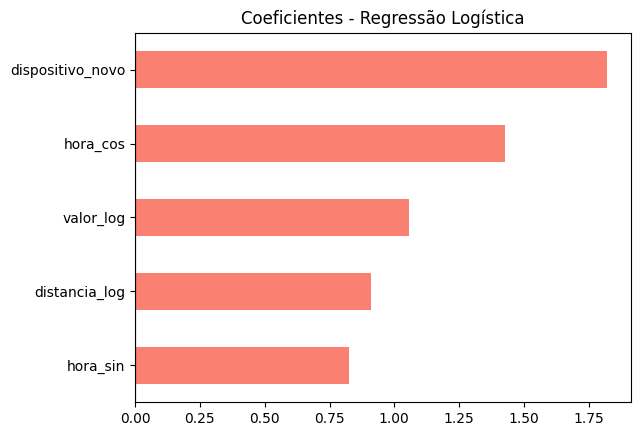

In [23]:
import matplotlib.pyplot as plt

# --- Random Forest ---
importances = pipeline_rf.named_steps['model'].feature_importances_
feature_names = X.columns
rf_importance = pd.Series(importances, index=feature_names).sort_values(ascending=True)

plt.figure()
rf_importance.plot(kind='barh', color='skyblue')
plt.title('Feature Importance - Random Forest')
plt.show()

# --- Regressão Logística ---
coeffs = pipeline_lr.named_steps['model'].coef_[0]
lr_importance = pd.Series(coeffs, index=feature_names).sort_values(ascending=True)

plt.figure()
lr_importance.plot(kind='barh', color='salmon')
plt.title('Coeficientes - Regressão Logística')
plt.axvline(0, color='black', lw=0.8)
plt.show()